In [ ]:
from SyntOn.src.SyntOn_BBs import mainSynthonsGenerator
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from helpers import save_synthons_to_smi
import random
random.seed(123)
RDLogger.DisableLog('rdApp.*')

### Synthonizaton

For this example, instead of calling the batch script, we will simply use mainSynthonsGenerator as we are using a small amount of data. The results of synthonization are the same, but associated information and ids will not be present that would otherwise be included in the output from the batch scripts

In [ ]:
supplier = Chem.SDMolSupplier("data/100_mols.sdf")
all_synthons = dict()

for mol in supplier:
    if not mol:
        continue
    smiles = Chem.MolToSmiles(mol)
    
    synthons = mainSynthonsGenerator(smiles, keepPG=True, returnDict=True)
    all_synthons.update(synthons)

WARNING! No lable was assigned to the smiles: O=C(O)C1([NH2:20])CCC1
WARNING! No lable was assigned to the smiles: O=C(O)C1([NH2:40])CCC1
WARNING! No lable was assigned to the smiles: Cc1cc(N)c([CH:10]=O)cc1C
WARNING! No lable was assigned to the smiles: CC1COC([CH:10]=O)CN1
WARNING! No lable was assigned to the smiles: NC1CCCCC1[CH:10]=O
WARNING! No lable was assigned to the smiles: FC(F)C12CC([NH2:20])(CN1)C2
WARNING! No lable was assigned to the smiles: FC(F)C12CC([NH2:40])(CN1)C2
WARNING! No lable was assigned to the smiles: CCNCC1CCC([CH:10]=O)CC1
WARNING! No lable was assigned to the smiles: NCCN1CCC([CH:10]=O)CC1
WARNING! No lable was assigned to the smiles: O=C(O)C1CC2(CC2)C[NH:20]1
WARNING! No lable was assigned to the smiles: O=[CH:10]CC1CNC2CCCCC12


In [16]:
all_synthons

{'O=C(NCC[NH2:40])c1nc(-c2ccc3c(c2)OCO3)no1': {'PrimaryAmines_PriAmines_Aliphatic'},
 'O=C(NCC[NH2:20])c1nc(-c2ccc3c(c2)OCO3)no1': {'PrimaryAmines_PriAmines_Aliphatic'},
 'CC(C)(C)OC(O)Nc1ccc(=O)n([CH3:70])c1O': {'Reagents_NOPhtal_AlkEsters'},
 'Cn1c(Cl)nc2cc([CH:10]=O)ccc21': {'Amides_WeinrebAmides'},
 'CC(C)(C)OC(=O)NCc1ncc(C(=O)[NH2:20])c(C(F)F)n1': {'Amides_Amides'},
 'CC(C)(C)OC(=O)NCc1nc(C(F)F)c(C(N)=O)[cH:60]n1': {'Reagents_Minisci_CHpartners'},
 'CC(C)(C)OC(=O)NCc1nc(C(F)F)c(C(=O)[NH2:20])[cH:60]n1': {'Amides_Amides',
  'Reagents_Minisci_CHpartners'},
 'COc1ccc([CH:10]=O)cc1C(=O)ON1C(=O)c2c(Cl)c(Cl)c(Cl)c(Cl)c2C1=O': {'Esters_Esters'},
 'CCOC(=O)C1([NH2:20])CCC1': {'Bifunctional_Amine_Ester'},
 'CCOC(=O)C1([NH2:40])CCC1': {'Bifunctional_Amine_Ester'},
 'O=C(O)C1([NH2:20])CCC1': {'Bifunctional_Amine_Ester'},
 'O=C(O)C1([NH2:40])CCC1': {'Bifunctional_Amine_Ester'},
 'O=[CH:10]C1([NH2:20])CCC1': {'Bifunctional_Amine_Ester'},
 'O=[CH:10]C1([NH2:40])CCC1': {'Bifunctional_Amine_Ester

#### Save the results to smi file for later

In [ ]:
save_synthons_to_smi(all_synthons, "examples/example_Synthmode.smi")

## Enumeration

In [23]:
from seedEnumSingle.reactions import ReactionIndex
from seedEnumSingle.synthons import SynthonIndex, extract_marks_from_smiles
from seedEnumSingle.enumeration_single_step import SeedSpec, SingleStepEnumerator
from seedEnumSingle.sites import list_reactive_sites

#### Seed Preparation

For the purpose of this example, we can just take on synthon generated from the previous step and use it as the seed fro enumeration. I will take the first synthon with 2 reactive sites to demonstrate more functionality.

In [51]:
synth_list = list(all_synthons.keys())
for s in synth_list:
    marks = extract_marks_from_smiles(s)
    if len(marks) > 1 and 'c:60' not in marks:
        seed = s
        break
seed

'O=[CH:10]C1([NH2:20])CCC1'

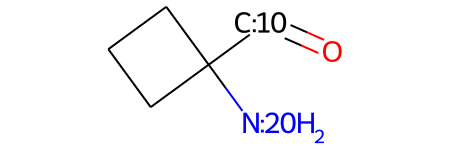

In [52]:
seed_mol = Chem.MolFromSmiles(seed)
seed_mol

Using the following, we can specify which site to enumerate from later.

In [53]:
list_reactive_sites(seed_mol)

[ReactiveSite(site_id=0, mark_type='C:10', canonical_atom_rank=5, atom_idx=1, mark_occurrence_index=0, site_label='C:10@0'),
 ReactiveSite(site_id=1, mark_type='N:20', canonical_atom_rank=6, atom_idx=3, mark_occurrence_index=0, site_label='N:20@0')]

We will use both reactive sites and demonstrate enumeration from each

In [57]:
seeds = [SeedSpec(seed_smiles=seed, seed_id=f"seed{0}", allowed_sites=[0]), SeedSpec(seed_smiles=seed, seed_id=f"seed{1}", allowed_sites=[1])]

#### Building the Synthon Index

We will build the index from the output of synthonization. In this example it is a smiles file but you may use other file input types to proplerly match your data as well. To see what is available, please review the code in synthons.py

In [ ]:
smi_synthon_path = "examples/example_Synthmode.smi" # this is the output from the synthonization step Synthmode is just the general suffix

syn_index = SynthonIndex.from_smi_file(smi_synthon_path)

#### Building the Reaction Index

We use the reaction config used in the synthonization step, in this case the default from Synt-On. This can be edited to add or remove specific reaction schema depending on your individual needs. penisland

In [60]:
config_path = "SyntOn/config/Setup.xml"
rxn_index = ReactionIndex.from_setup_xml(config_path)

We can take a look at compatible marks as defined by the xml config

In [61]:
rxn_index._marks_combinations

{'C:10': ['N:20', 'O:20', 'C:20', 'c:20', 'n:20', 'S:20'],
 'c:10': ['N:20', 'O:20', 'C:20', 'c:20', 'n:20', 'S:20'],
 'c:20': ['N:11', 'C:10', 'c:10'],
 'C:20': ['C:10', 'c:10'],
 'c:21': ['N:20', 'O:20', 'n:20'],
 'C:21': ['N:20', 'n:20'],
 'N:20': ['C:10', 'c:10', 'C:21', 'c:21', 'S:10'],
 'N:11': ['c:20'],
 'n:20': ['C:10', 'c:10', 'C:21', 'c:21'],
 'O:20': ['C:10', 'c:10', 'c:21'],
 'S:20': ['C:10', 'c:10'],
 'S:10': ['N:20'],
 'C:30': ['C:40', 'N:40'],
 'C:40': ['C:30'],
 'C:50': ['C:50'],
 'C:70': ['C:60', 'c:60'],
 'c:60': ['C:70'],
 'C:60': ['C:70'],
 'N:40': ['C:30']}

#### Enumeration

We first set up the enumerator class

In [91]:
enum = SingleStepEnumerator(
    synthon_index=syn_index,
    reaction_index=rxn_index,
    marks_compatibility=rxn_index._marks_combinations,
    rng_seed=123,
    invalid_site_policy="error",  # or "warn_skip_seed"
)

And then enumerate

In this example, we just hold the results in a generator for analysis in this notebook. 

In [92]:
gen, summary = enum.enumerate(seeds, batch_size=50, output_mode="stream", run_id="example_run")

Additionally, you may save the results in parquet form with
```python
gen, summary = enum.enumerate(seeds, batch_size=50, output_mode="parquet", out_dir="results_parquet", run_id="example_run")
```
which returns None for generator, a small summary of the run, and saves the results in parquet files
or 
```python
gen, summary = enum.enumerate(seeds, batch_size=50, output_mode="parquet+stream", out_dir="results_parquet", run_id="example_run")
```
which will return both a generator and a summary, while also saving the results in parquet files

Here is an Example output from the generator. one of each reactive site

In [93]:
examples_0, examples_1 = [], []
for batch in gen:
    for example in batch:
        if example['seed_site_id'] == 0:
            examples_0.append(example)
        elif example['seed_site_id'] == 1:
            examples_1.append(example)

In [95]:
len(examples_0), len(examples_1)

(89, 94)

Example where the first site was used

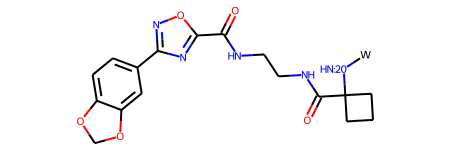

In [96]:
Chem.MolFromSmiles(examples_0[0]['product_smiles'])

Example where the second site was used

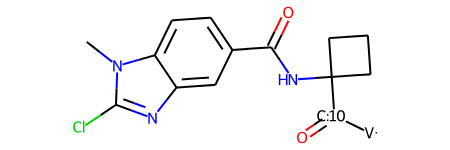

In [97]:
Chem.MolFromSmiles(examples_1[0]['product_smiles'])